In [60]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, ShallowDataLoaderManager, GraphDataLoaderManager, DeepDataLoaderManager
from src.models import ConstantModel, PersistenceModel, ClimateologyModel, NodeLSTMModel, NodeGRUModel, GATv2Model, SpatialGNNModel

# get data
disease_name    = 'covid'
nuts_level      = 'nuts3'
min_date        = '2020-06-01'
max_date        = '2023-01-01'
split_trainval  = '2022-06-01'
split_valtest   = '2022-09-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 2
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = True,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0  
    )    

data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: /local/job_23330068/wissdaten/ZKI-PH4/deschrijvers_wissdaten/data/processed/germany/geospatial/shapefiles/shape_nuts3.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


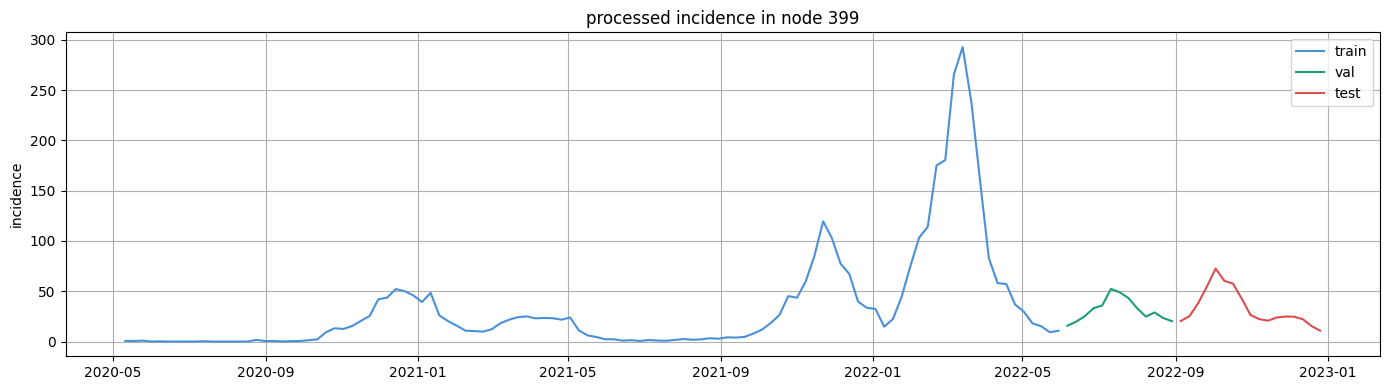

In [61]:
data_orchestrator.preview(399, 'processed').show()

In [62]:


shallowdata         = ShallowDataLoaderManager(data_orchestrator).construct_dataloaders()
graphdataloader_id  = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('identity_graph').construct_dataloaders()
graphdataloader_bn  = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('geographical_neighbors1').construct_dataloaders()
graphdataloader_cm2 = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter24_1').construct_dataloaders()


ps = PersistenceModel(shallowdata)
ps.forecast('test')


# spatiotemporal_model1 = GATv2Model(graphdataloader_id, name = 'GATv2 identity_graph')
# spatiotemporal_model1.set_model_hparams()
# spatiotemporal_model1.set_global_hparams(**global_hparams)
# spatiotemporal_model1.train()
# spatiotemporal_model1.forecast('test')



# spatiotemporal_model3 = GATv2Model(graphdataloader_cm2, name = 'GATv2 commuter 3')
# spatiotemporal_model3.set_model_hparams()
# spatiotemporal_model3.set_global_hparams(**global_hparams)
# spatiotemporal_model3.train()
# spatiotemporal_model3.forecast('test')

PersistenceModel(name='persistence_model')


==           gatv2_boolean_neighbors            ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 4, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 1 train loss: 0.6922, val loss: 0.3939 (patience: 1/20)
Epoch 11 train loss: 0.2089, val loss: 0.1553 ✓ (new best)
Epoch 21 train loss: 0.1519, val loss: 0.1042 ✓ (new best)
Epoch 31 train loss: 0.1297, val loss: 0.0975 (patience: 1/20)
Epoch 41 train loss: 0.1160, val loss: 0.0941 (patience: 1/20)
Epoch 51 train loss: 0.1085, val loss: 0.1538 (patience: 2/20)
lr has been updated from 1.00e-04 to 7.50e-05
Epoch 61 train loss: 0.0878, val loss: 0.1290 (patience: 12/20)
lr has been updated from 7.50e-05 to 5.63e-05
Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.0918
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 449.38it/s]

Test loss: 0.0897
forecasted ✓


GATv2Model(name='gatv2_boolean_neighbors')

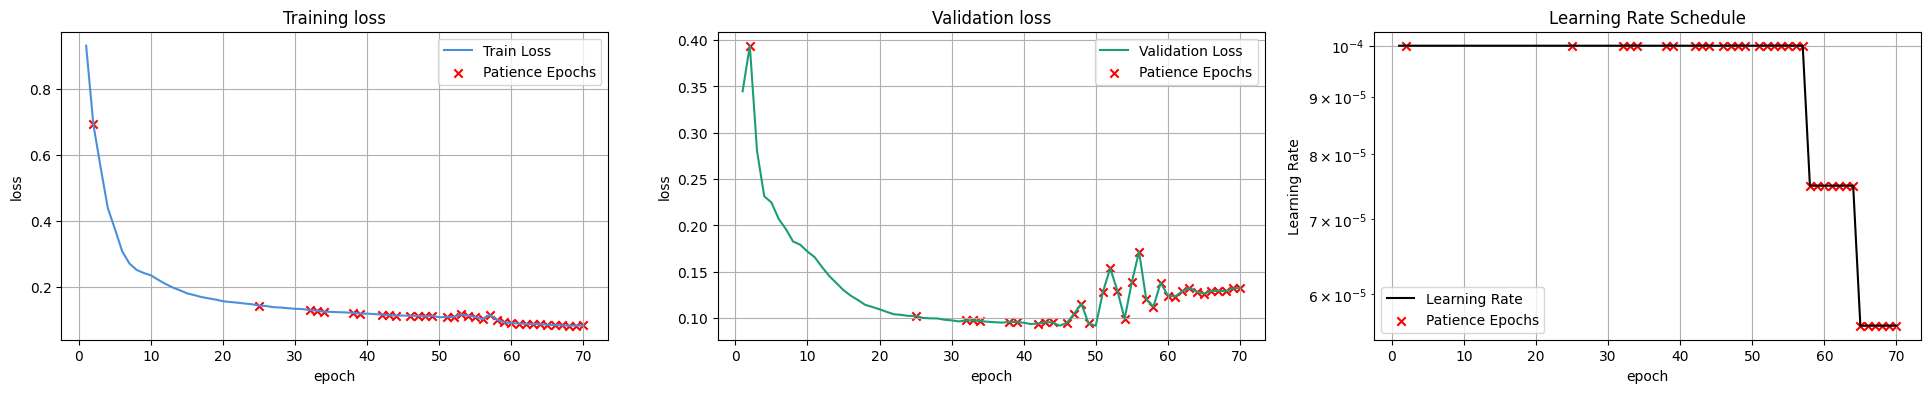

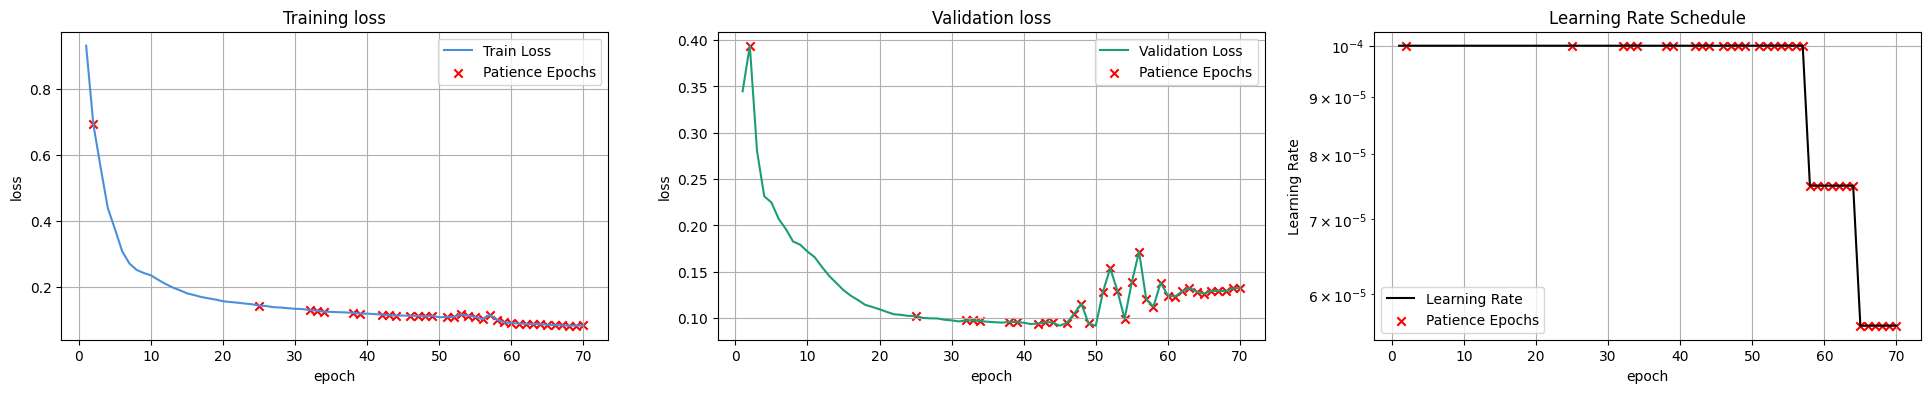

In [63]:
global_hparams = {
    "lr"                : 0.0001,
    "n_epochs"          : 100,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.75, 'patience': 6, 'min_lr': 1e-8},
    'min_delta'         : 0,
    'loss'              : 'mse',
    'patience'          : 20,
    }

spatiotemporal_model2 = GATv2Model(graphdataloader_bn, name = 'GATv2 boolean neighbors',verbose = 2)
spatiotemporal_model2.set_model_hparams()
spatiotemporal_model2.set_global_hparams(**global_hparams)
spatiotemporal_model2.train()
spatiotemporal_model2.forecast('test')


==            gcn_boolean_neighbors             ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 4, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 1 train loss: 0.9129, val loss: 0.9070 ✓ (new best)
Epoch 11 train loss: 0.1590, val loss: 0.0989 ✓ (new best)
lr has been updated from 1.00e-04 to 7.50e-05
Epoch 21 train loss: 0.1399, val loss: 0.1071 (patience: 9/20)
lr has been updated from 7.50e-05 to 5.63e-05
Epoch 31 train loss: 0.1336, val loss: 0.1124 (patience: 19/20)
Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.0983
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 580.64it/s]

Test loss: 0.1329
forecasted ✓


SpatialGNNModel(name='gcn_boolean_neighbors')

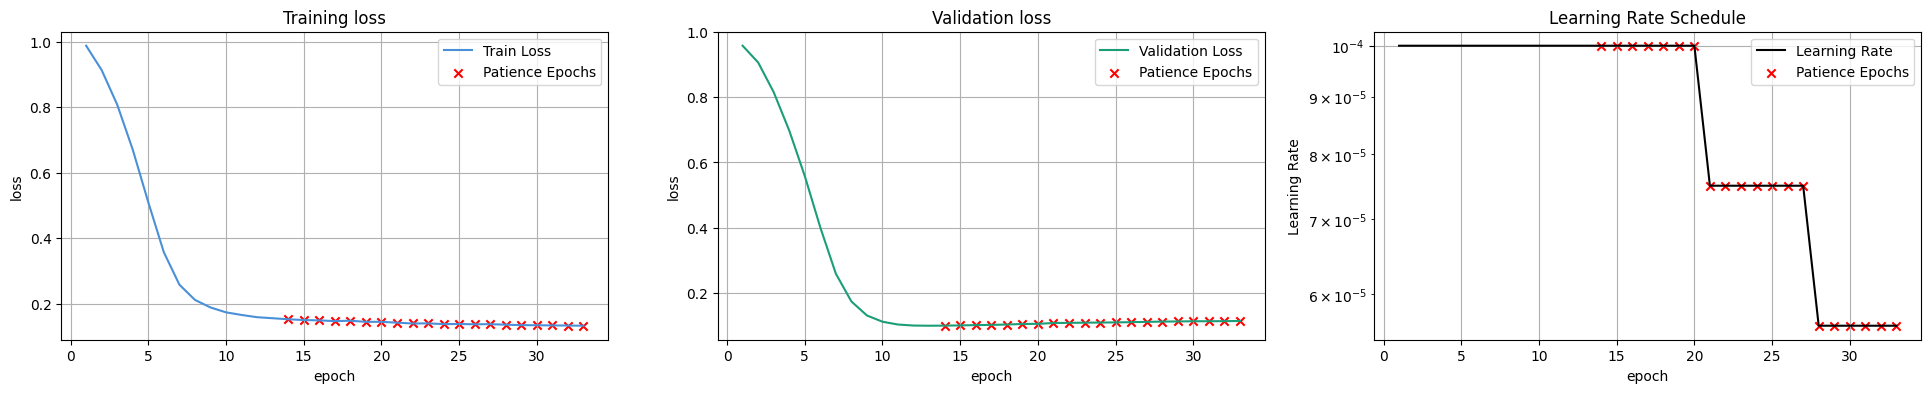

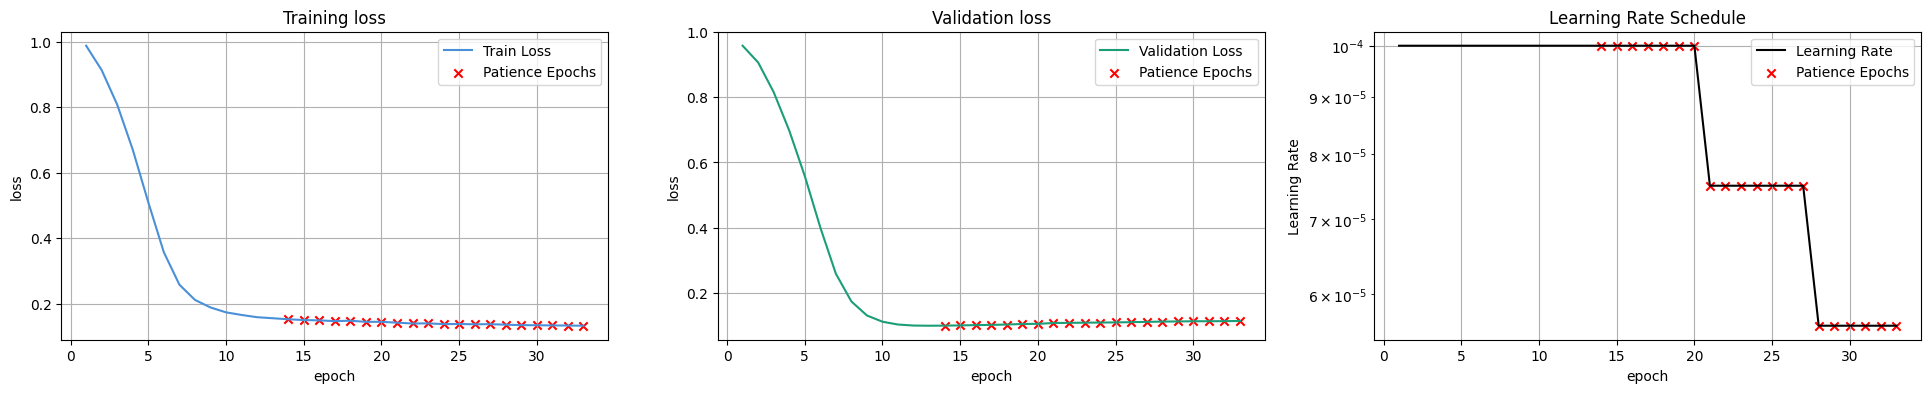

In [64]:
global_hparams = {
    "lr"                : 0.0001,
    "n_epochs"          : 100,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.75, 'patience': 6, 'min_lr': 1e-8},
    'min_delta'         : 0,
    'loss'              : 'mse',
    'patience'          : 20,
    }

spatial_model2 = SpatialGNNModel(graphdataloader_bn, name = 'GCN boolean neighbors',verbose = 2)
spatial_model2.set_model_hparams()
spatial_model2.set_global_hparams(**global_hparams)
spatial_model2.train()
spatial_model2.forecast('test')

Forecasting train: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 108/108 [00:00<00:00, 450.59it/s]


Train loss: 0.0585
forecasted ✓


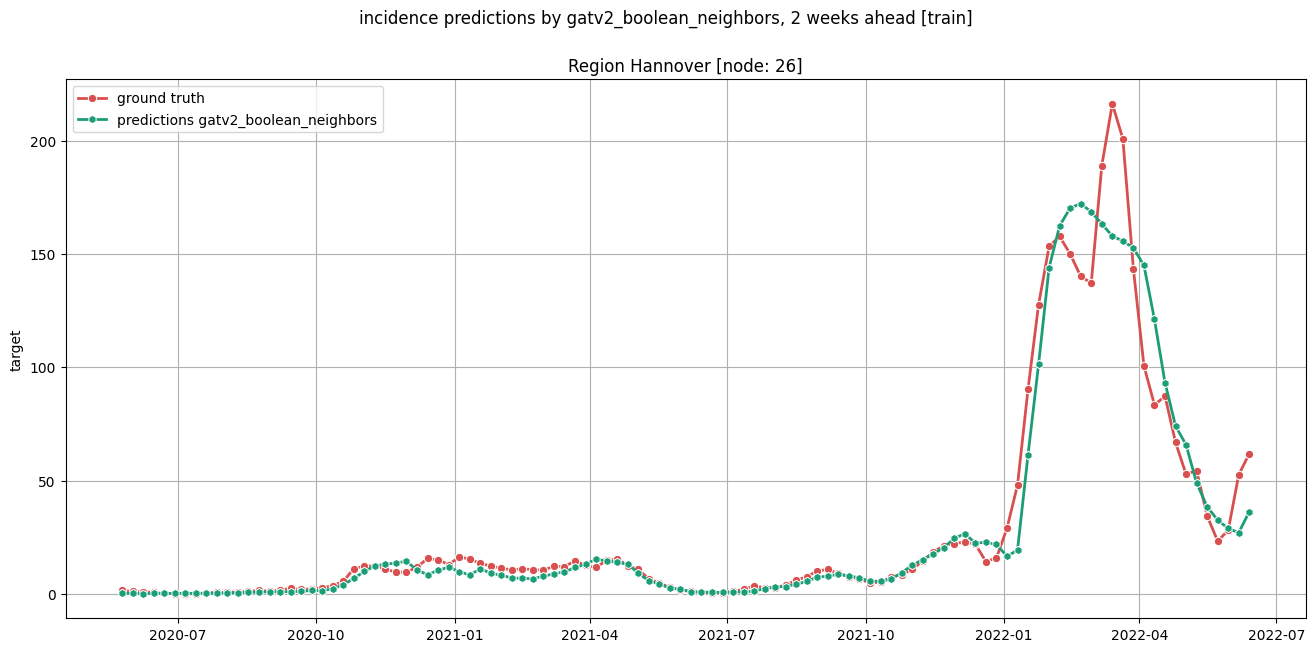

In [65]:
# spatiotemporal_model2.forecast('test')
# spatiotemporal_model2.forecast('train')
spatiotemporal_model2.forecast('train')
spatiotemporal_model2.show_forecasts(26, 'train').show()

Forecasting train: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 108/108 [00:00<00:00, 635.26it/s]


Train loss: 0.0966
forecasted ✓


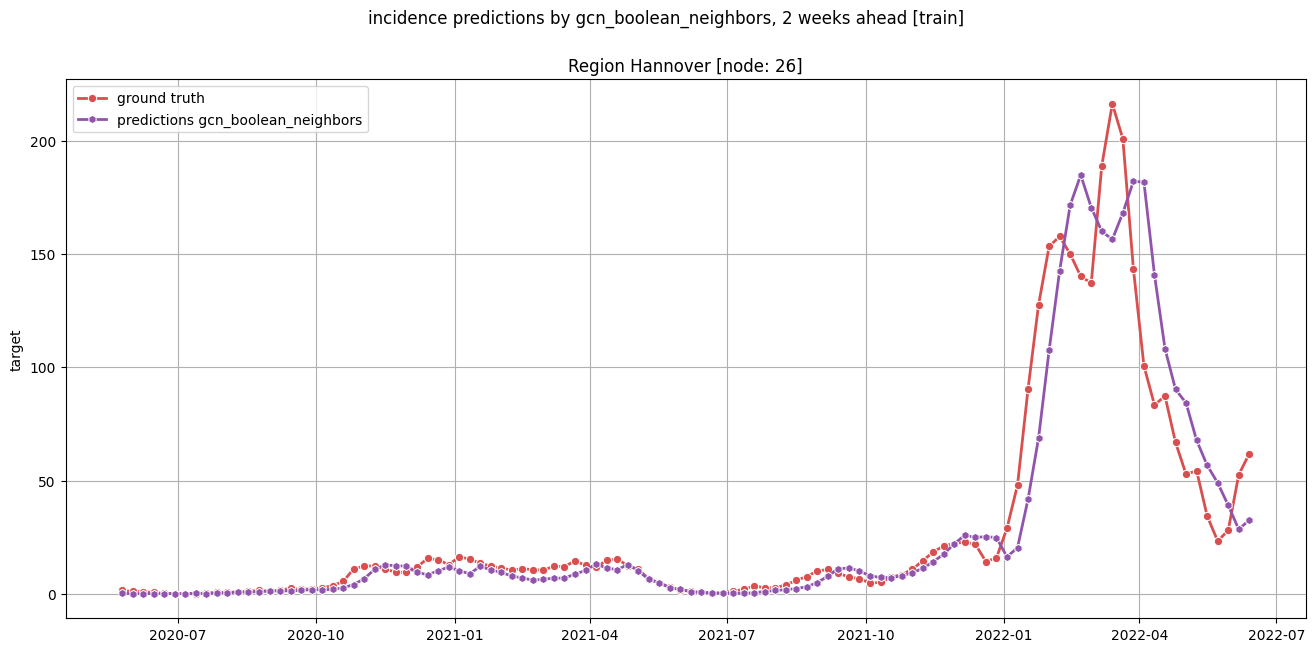

In [66]:
spatial_model2.forecast('train')
spatial_model2.show_forecasts(26, 'train').show()


==               gatv2_commuter_3               ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 4, 1), y=(400, 1), edge_index=(2, 3905), edge_weight=(3905,))
Epoch 1 train loss: 0.6178, val loss: 0.3319 ✓ (new best)
Epoch 11 train loss: 0.2164, val loss: 0.1463 ✓ (new best)
Epoch 21 train loss: 0.1475, val loss: 0.0839 ✓ (new best)
Epoch 31 train loss: 0.1250, val loss: 0.0811 (patience: 4/20)
lr has been updated from 1.00e-04 to 5.00e-05
Epoch 41 train loss: 0.1005, val loss: 0.0995 (patience: 14/20)
lr has been updated from 5.00e-05 to 2.50e-05
Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.0756
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 428.61it/s]

Test loss: 0.1052
forecasted ✓


GATv2Model(name='gatv2_commuter_3')

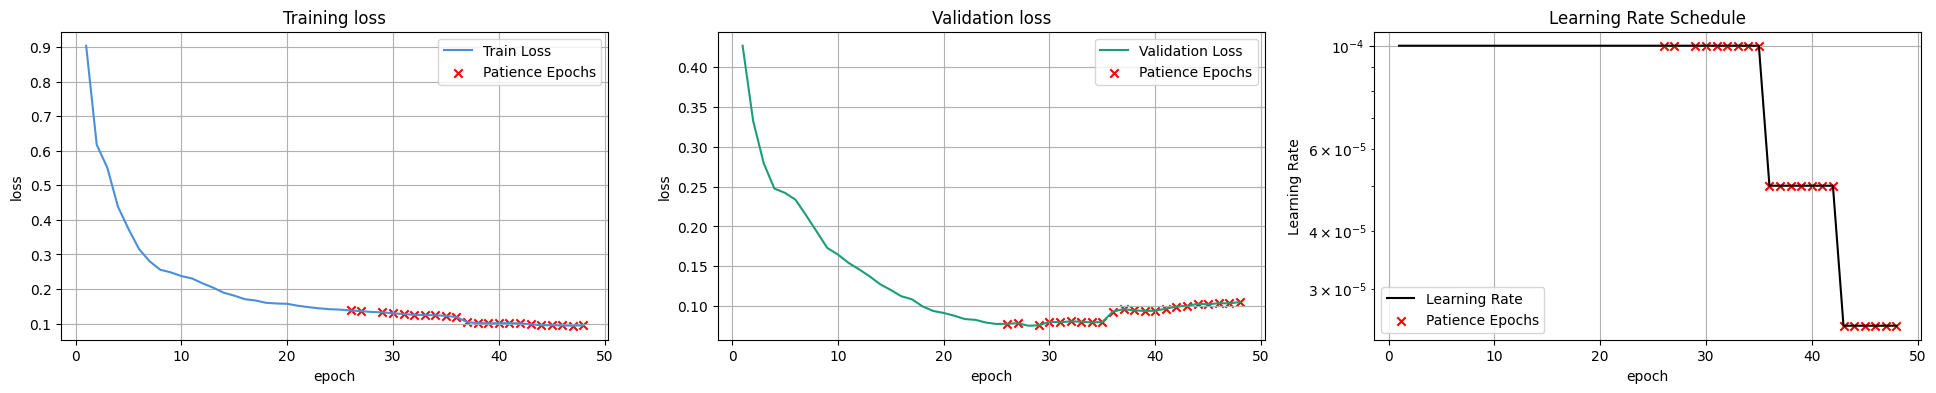

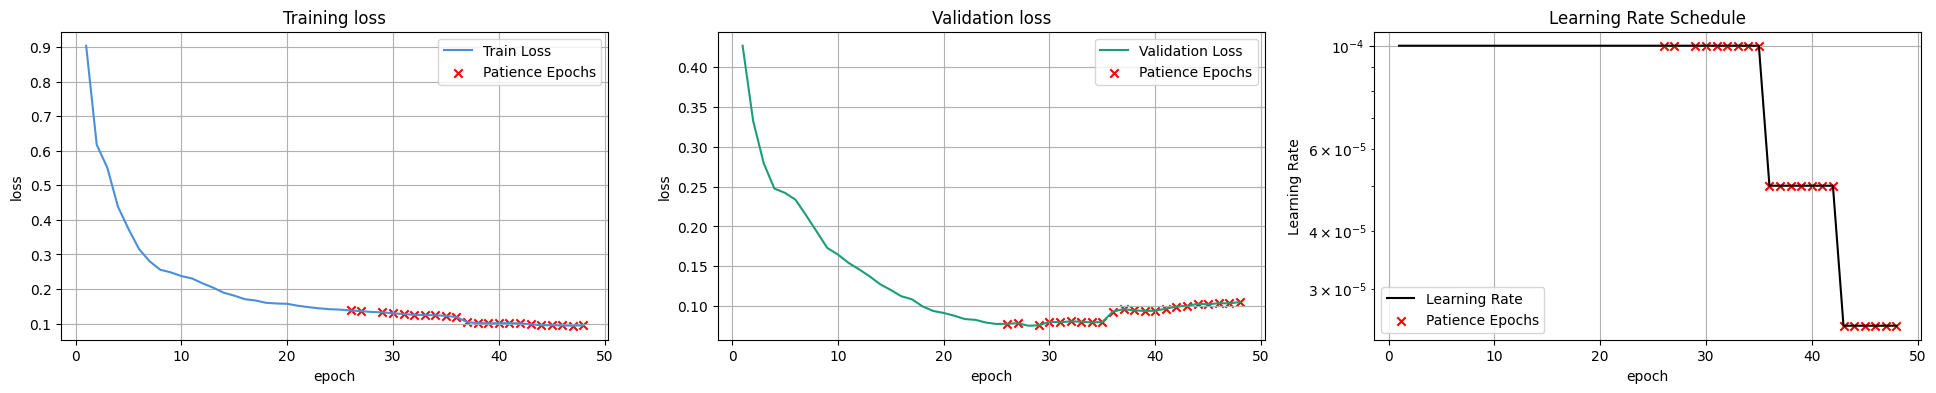

In [72]:
global_hparams = {
    "lr"                : 0.0001,
    "n_epochs"          : 100,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.5, 'patience': 6, 'min_lr': 1e-8},
    'min_delta'         : 0,
    'loss'              : 'mse',
    'patience'          : 20,
    }


spatiotemporal_model3 = GATv2Model(graphdataloader_cm2, name = 'GATv2 commuter 3', verbose = 2)
spatiotemporal_model3.set_model_hparams()
spatiotemporal_model3.set_global_hparams(**global_hparams)
spatiotemporal_model3.train()
spatiotemporal_model3.forecast('test')

Forecasting train: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 108/108 [00:00<00:00, 432.66it/s]


Train loss: 0.0683
forecasted ✓


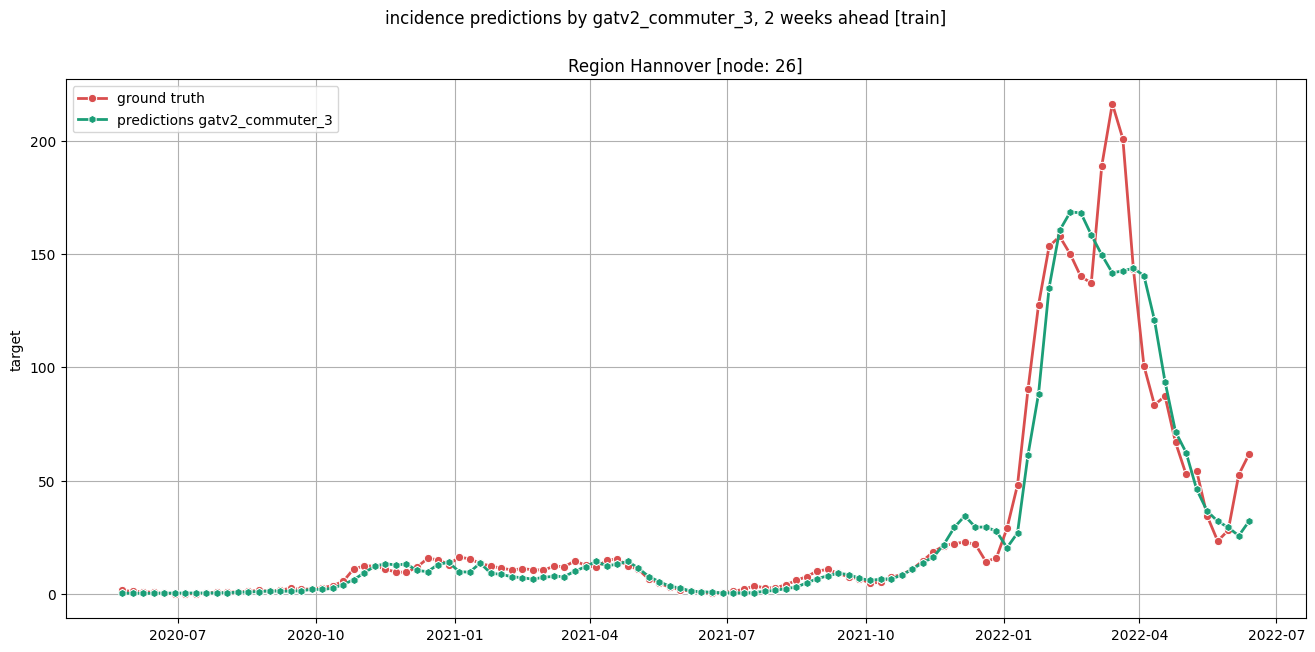

In [73]:
spatiotemporal_model3.forecast('train')
spatiotemporal_model3.show_forecasts(26, 'train').show()

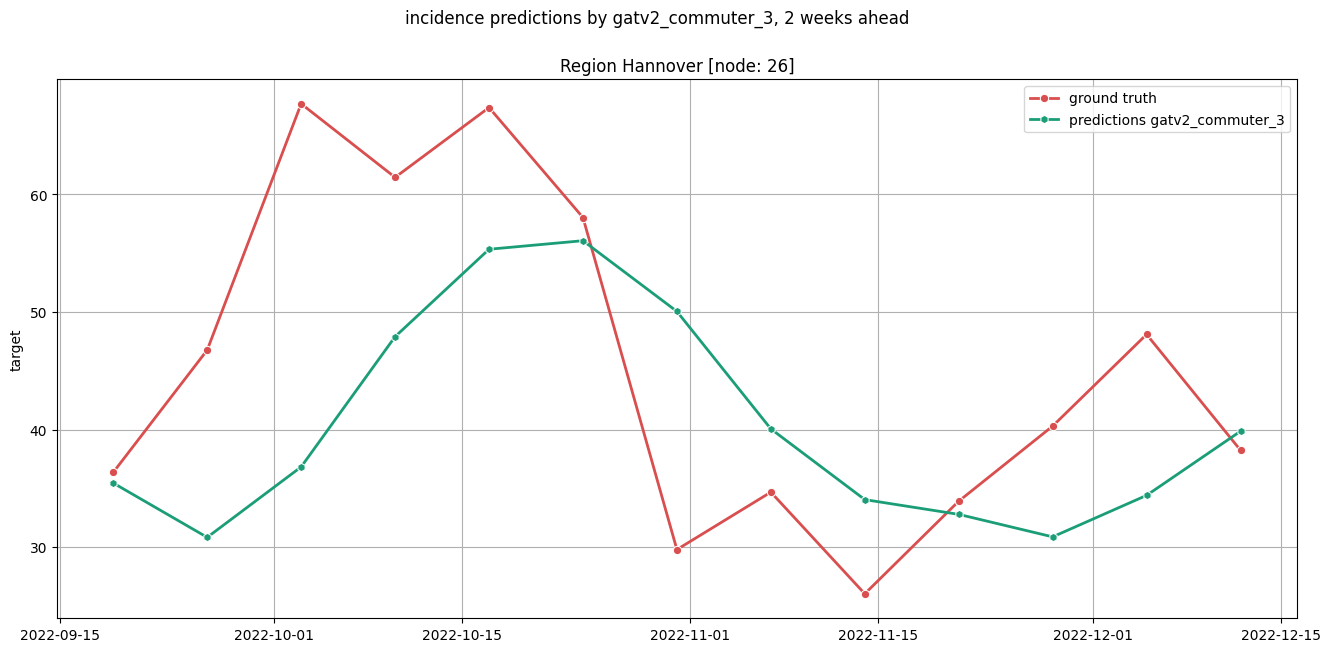

In [74]:
spatiotemporal_model3.show_forecasts(26).show()

In [75]:
from src.evaluation import Evaluator

e = Evaluator([ps, spatiotemporal_model3, spatial_model2]).add_evaluation()

computing metrics: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:02<00:00,  2.06it/s]


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplott

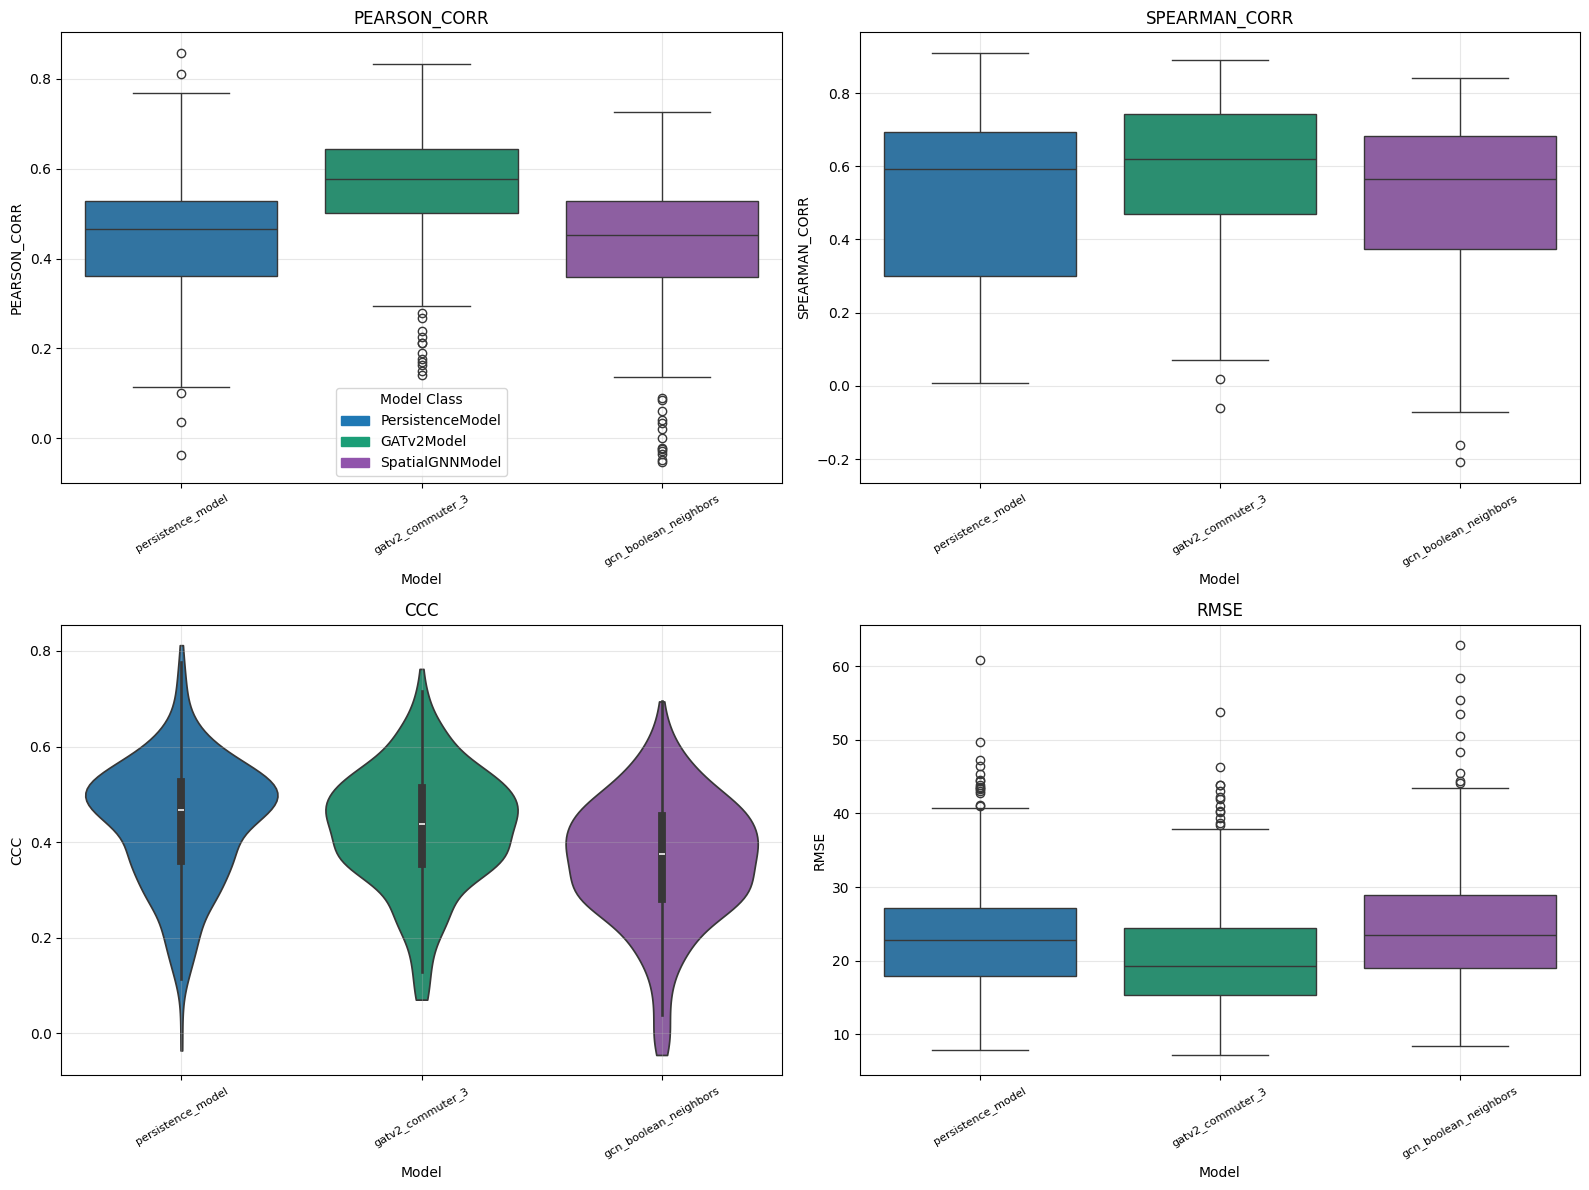

In [76]:
e.plotter.plot_metric_compilation().show()